### SVM for fashion_mnist

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = fetch_openml(name='Fashion-MNIST', version=1, return_X_y=True, as_frame=False)

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

subset_size = 5000
X_train_subset = X_train_scaled[:subset_size]
y_train_subset = y_train[:subset_size]

svc_model = SVC(kernel='rbf', C=1.0, verbose=1)
svc_model.fit(X_train_subset, y_train_subset)

[LibSVM]

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,1


In [6]:
import joblib
joblib.dump(svc_model, 'svc_model_fashion_mnist.joblib')
print("SVC model saved successfully as 'svc_model_fashion_mnist.joblib'")

SVC model saved successfully as 'svc_model_fashion_mnist.joblib'


SVC Model Accuracy: 0.8414

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.80      1394
           1       0.99      0.95      0.97      1402
           2       0.81      0.73      0.77      1407
           3       0.83      0.88      0.85      1449
           4       0.72      0.81      0.76      1357
           5       0.93      0.90      0.91      1449
           6       0.64      0.55      0.59      1407
           7       0.87      0.91      0.89      1359
           8       0.90      0.96      0.93      1342
           9       0.93      0.92      0.92      1434

    accuracy                           0.84     14000
   macro avg       0.84      0.84      0.84     14000
weighted avg       0.84      0.84      0.84     14000



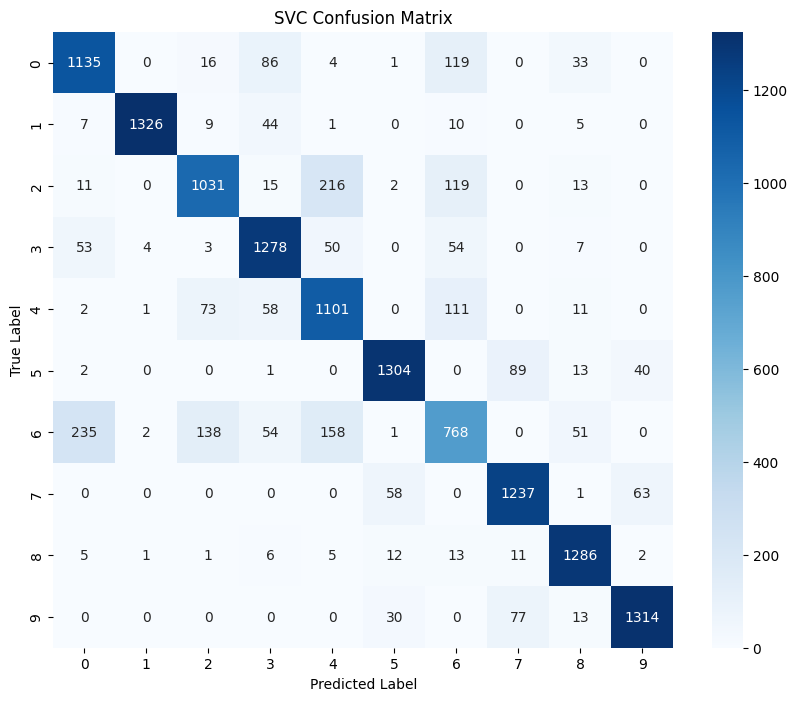

In [ ]:
y_pred_svc = svc_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_svc)
print(f"SVC Model Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_svc))

conf_matrix = confusion_matrix(y_test, y_pred_svc)
class_labels = sorted(np.unique(y))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVC Confusion Matrix')
plt.show()

In [1]:
import numpy as np

# Your sample array
my_array = np.array([2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 0, 2, 1, 2, 2, 1, 2,
                     2, 1, 2, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
                     2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2,
                     2, 2, 2, 2, 1, 0, 1, 1, 2, 2, 1, 2, 2, 1, 1, 1, 2, 2, 2,
                     2, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2, 1, 2, 2, 0, 2, 1, 2, 1,
                     1, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 2, 2,
                     2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1,
                     1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
                     2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1,
                     1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
                     2, 2, 2, 2, 1, 2, 2, 0, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
                     2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
                     2, 2, 2, 2])

# Find all values equal to 0
zero_values = my_array[my_array == 0]

print(zero_values)

[0 0 0 0 0 0]


### SVC for fashion_dataset using dimensionality reduction PCA

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = fetch_openml(name='Fashion-MNIST', version=1, return_X_y=True, as_frame=False)

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features: {pca.n_components_}")

Original number of features: 784
Reduced number of features: 256


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

svc_pca = SVC(kernel='rbf', verbose=1)
svc_pca.fit(X_train_pca, y_train)

y_pred_pca_svc = svc_pca.predict(X_test_pca)
print("\nSVC with PCA Classification Report:")
print(classification_report(y_test, y_pred_pca_svc))

accuracy = accuracy_score(y_test, y_pred_pca_svc)
print(f"SVC with PCA Accuracy: {accuracy:.4f}")

[LibSVM]
SVC with PCA Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1394
           1       0.99      0.97      0.98      1402
           2       0.83      0.82      0.83      1407
           3       0.88      0.91      0.90      1449
           4       0.80      0.83      0.82      1357
           5       0.97      0.96      0.96      1449
           6       0.74      0.66      0.70      1407
           7       0.93      0.96      0.95      1359
           8       0.95      0.98      0.96      1342
           9       0.97      0.95      0.96      1434

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000

SVC with PCA Accuracy: 0.8904


In [7]:
import joblib
# Save the model to a file
joblib.dump(svc_pca, 'svc_pca_fashion_mnist.joblib')
print("Model saved successfully as 'svc_pca_fashion_mnist.joblib'")

Model saved successfully as 'svc_pca_fashion_mnist.joblib'


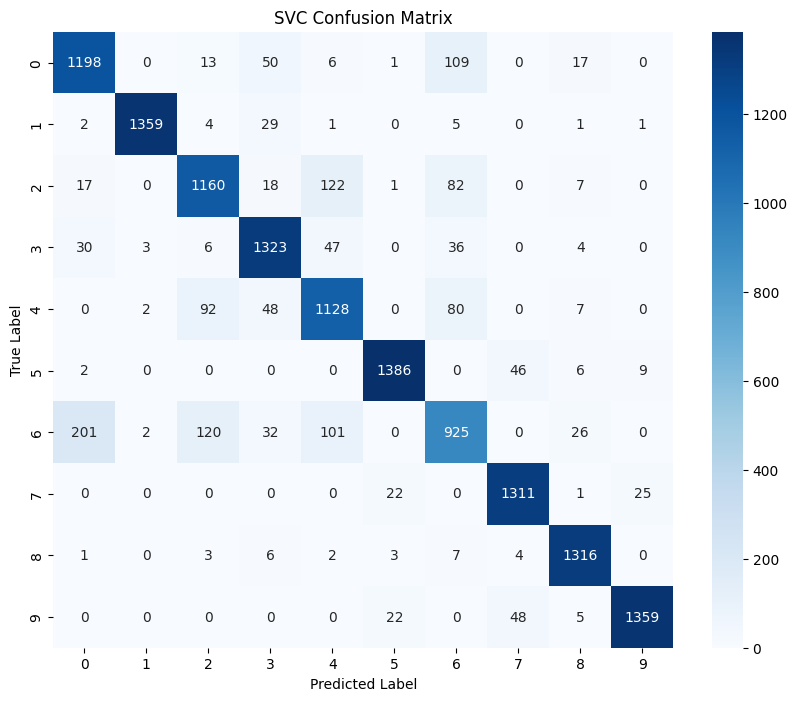

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import  confusion_matrix
# Generate and plot the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_pca_svc)
class_labels = sorted(np.unique(y))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVC Confusion Matrix')
plt.show()